# get_reachable_demo — Reachability analysis in DuckifySim

Usage:
- Open this notebook in the DuckifySim environment.
- Run cells top-to-bottom to sample mesh points and evaluate reachable TCP directions.
- Visualize reachable directions and unreachable regions directly in 3-D.

MIT License

Copyright (c) 2026 Nathan Antonietti

Permission is hereby granted, free of charge, to any person obtaining a copy of this software and associated documentation files (the "Software"), to deal in the Software without restriction, including without limitation the rights to use, copy, modify, merge, publish, distribute, sublicense, and/or sell copies of the Software, and to permit persons to whom the Software is furnished to do so, subject to the following conditions:

The above copyright notice and this permission notice shall be included in all copies or substantial portions of the Software.

THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY, FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL THE AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER LIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING FROM, OUT OF OR IN CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER DEALINGS IN THE SOFTWARE.

Author:     Nathan Antonietti, with assistance from Copilot (Microsoft)
Course:     HES-SO Valais-Wallis, Engineering Track 304

# `get_reachable` — Cone Sampling on cube.stl

For each sampled point on the cube surface this notebook calls `get_reachable`,
which sweeps approach directions inside a cone around the face normal and
returns every collision-free TCP6D pose.

Results are visualised as:
- **Green arrows** → reachable approach directions
- **Red dots** → points where *no* direction in the cone was reachable
- **Black star** → robot base (origin)


In [1]:
import numpy as np
import matplotlib
from IPython import get_ipython

ip = get_ipython()
selected_backend = None
for candidate in ("tk", "notebook", "inline"):
    try:
        if ip is not None:
            ip.run_line_magic("matplotlib", candidate)
        else:
            matplotlib.use({"tk": "TkAgg", "notebook": "nbAgg", "inline": "Agg"}[candidate])
        selected_backend = candidate
        break
    except Exception:
        pass

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

print(f"Matplotlib backend: {matplotlib.get_backend()} (mode: {selected_backend})")


Matplotlib backend: inline (mode: inline)


In [2]:
import sys
from pathlib import Path
from math import pi

# Make sure ur3e-control root is on the path
sys.path.insert(0, str(Path.cwd().parents[1]))

import trimesh
from duckify_simulation.duckify_sim import DuckifySim
from URBasic import Joint6D, TCP6D

from src.safety import get_reachable

# Connect to the simulator
duckify = DuckifySim()
robot = duckify.robot_control
print("Connected to simulator")


DuckifySim connected to container 'iscoin_simulator'
Connected to simulator


## Load cube.stl


In [3]:
mesh_path = "../3d_objects/duck.stl"
mesh = trimesh.load(mesh_path)

print(f"Loaded : {mesh_path}")
print(f"Vertices: {len(mesh.vertices)}")
print(f"Faces   : {len(mesh.faces)}")
print(f"Bounds  : {mesh.vertices.min(axis=0).round(4)}  →  {mesh.vertices.max(axis=0).round(4)}")
print(f"Centroid: {mesh.centroid.round(4)}")


Loaded : ../3d_objects/duck.stl
Vertices: 5335
Faces   : 10666
Bounds  : [-0.0371 -0.0493  0.001 ]  →  [0.0371 0.052  0.1048]
Centroid: [ 0.     -0.0034  0.0403]


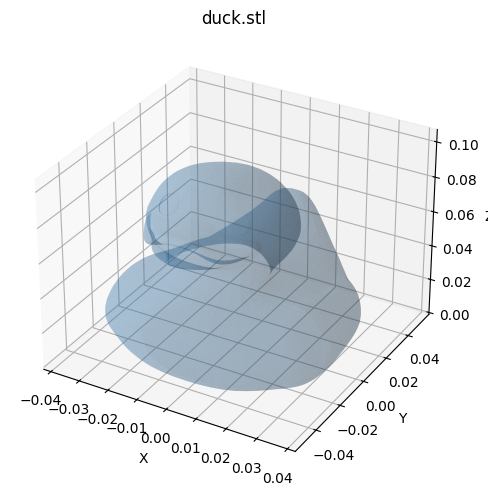

In [4]:
# Quick 3-D preview of the mesh
_large = len(mesh.faces) > 2000  # skip per-edge rendering on dense meshes

fig = plt.figure(figsize=(7, 5))
ax = fig.add_subplot(111, projection="3d")
ax.plot_trisurf(
    mesh.vertices[:, 0], mesh.vertices[:, 1], mesh.vertices[:, 2],
    triangles=mesh.faces, alpha=0.25, color="steelblue",
    edgecolor="none" if _large else "gray",
    linewidth=0.0 if _large else 0.3,
)
ax.set_xlabel("X"); ax.set_ylabel("Y"); ax.set_zlabel("Z")
ax.set_title(mesh_path.split("/")[-1])
plt.tight_layout()
plt.show()


## Parameters

Tune the cone sampling and obstacle scene here.


In [ ]:
# ── Cone sampling parameters ─────────────────────────────────────────────────
CONE_ANGLE  = pi / 3       # half-angle of the cone  (rad)  — 30°
STEP        = pi / 6       # azimuth step inside each tilt ring (rad) — 30°
TILT_STEP   = pi / 6       # spacing between tilt rings (rad) — 30°
ARROW_LEN   = 0.025        # length of drawn direction arrows in the plot
HAND_LEN    = 0.2215        # length of actual robot hand with pen
MAX_ARROWS  = 250          # cap on displayed arrows; one representative per point
                           # is kept when this limit is exceeded

# ── Sampling: one random point per face ──────────────────────────────────────
POINTS_PER_FACE = 1
SEED            = 42

# ── Obstacles ─────────────────────────────────────────────────────────────────
# Add / remove dicts here to change the scene.
obstacles = [
    # {"type": "box",    "center": [0.1, -0.15, 0.05], "size": [0.02, 0.1, 0.1]},
    # {"type": "sphere", "center": [0.20, 0.10, 0.10], "radius": 0.05},
]

print(f"Cone angle : {round(CONE_ANGLE * 180 / pi, 1)}°")
print(f"Step       : {round(STEP       * 180 / pi, 1)}°")
print(f"Tilt step  : {round(TILT_STEP  * 180 / pi, 1)}°")
print(f"Max arrows : {MAX_ARROWS}")
print(f"Obstacles  : {len(obstacles)}")


Cone angle : 60.0°
Step       : 30.0°
Tilt step  : 30.0°
Max arrows : 250
Obstacles  : 0


## Run `get_reachable` on sampled face points


In [6]:
try:
    from tqdm.notebook import tqdm as _tqdm
except ImportError:
    try:
        from tqdm import tqdm as _tqdm
    except ImportError:
        _tqdm = None  # progress bar unavailable

def _safe_unit(v, fallback=(0.0, 0.0, 1.0)):
    v = np.asarray(v, dtype=float)
    n = np.linalg.norm(v)
    if n < 1e-12:
        v = np.asarray(fallback, dtype=float)
        n = np.linalg.norm(v)
    return v / n

def sample_face_points(mesh, points_per_face=1, seed=42):
    """Sample `points_per_face` random barycentric points per triangle face."""
    rng = np.random.default_rng(seed)
    pts, normals = [], []
    has_fn = len(mesh.face_normals) == len(mesh.faces)
    for fid, tri in enumerate(mesh.faces):
        v0, v1, v2 = mesh.vertices[tri]
        n_raw = mesh.face_normals[fid] if has_fn else np.cross(v1 - v0, v2 - v0)
        n = _safe_unit(n_raw, fallback=np.cross(v1 - v0, v2 - v0))
        r1, r2 = rng.random(points_per_face), rng.random(points_per_face)
        sr1 = np.sqrt(r1)
        p = (1 - sr1)[:, None] * v0 + (sr1 * (1 - r2))[:, None] * v1 + (sr1 * r2)[:, None] * v2
        pts.append(p)
        normals.append(np.tile(n, (points_per_face, 1)))
    return np.vstack(pts), np.vstack(normals)


# ── Sample points on the mesh ─────────────────────────────────────────────────
sample_pts, sample_normals = sample_face_points(mesh, POINTS_PER_FACE, SEED)
print(f"Sampled {len(sample_pts)} points ({POINTS_PER_FACE} per face × {len(mesh.faces)} faces)")

# ── Evaluate get_reachable at each point ──────────────────────────────────────
results = []   # list of dicts: point, normal, poses (list[TCP6D])

_iter = zip(sample_pts, sample_normals)
if _tqdm is not None:
    _iter = _tqdm(list(_iter), desc="get_reachable", unit="pt")

for p, n in _iter:
    n_safe = _safe_unit(n)
    tcp6d_in = [float(p[0]), float(p[1]), float(p[2]),
                float(n_safe[0]), float(n_safe[1]), float(n_safe[2])]

    poses = get_reachable(
        tcp6d_in,
        obstacles if obstacles else None,
        cone_angle=CONE_ANGLE,
        step=STEP,
        tilt_step=TILT_STEP,
    )
    results.append({"point": p.copy(), "normal": n_safe.copy(), "poses": poses})

n_with_any   = sum(1 for r in results if r["poses"])
n_fully_none = sum(1 for r in results if not r["poses"])
total_poses  = sum(len(r["poses"]) for r in results)

print(f"\nPoints with ≥1 reachable direction : {n_with_any}/{len(results)}")
print(f"Points with no reachable direction  : {n_fully_none}/{len(results)}")
print(f"Total reachable poses collected     : {total_poses}")


Sampled 10666 points (1 per face × 10666 faces)

Points with ≥1 reachable direction : 10666/10666
Points with no reachable direction  : 0/10666
Total reachable poses collected     : 266650


## Visualisation (interactive — Plotly)

- **Coloured dots** — sampled points coloured by number of reachable directions (viridis: purple → low, yellow → high); hover to see coords, normal and count
- **Green cones** — one representative approach direction per point (capped at `MAX_ARROWS`); hover for direction vector
- **Red dots** — points where the cone contained *no* reachable direction


In [ ]:
import plotly.graph_objects as go
from scipy.spatial.transform import Rotation as ScipyRot

def tcp6d_z_axis(tcp6d_obj):
    """Return the z-axis (approach direction) of a TCP6D pose as a unit vector."""
    rv = np.array([tcp6d_obj.rx, tcp6d_obj.ry, tcp6d_obj.rz], dtype=float)
    return ScipyRot.from_rotvec(rv).as_matrix()[:, 2]


# ── Build per-point data ───────────────────────────────────────────────────────
pt_positions = np.array([r["point"] for r in results])          # (N, 3)
pt_counts    = np.array([len(r["poses"]) for r in results])     # (N,)

rep_origins, rep_dirs = [], []
failed_pts = []
for r in results:
    if r["poses"]:
        rep_origins.append(r["point"])
        rep_dirs.append(tcp6d_z_axis(r["poses"][0]))
    else:
        failed_pts.append(r["point"])

rep_origins = np.array(rep_origins) if rep_origins else np.empty((0, 3))
rep_dirs    = np.array(rep_dirs)    if rep_dirs    else np.empty((0, 3))
failed_pts  = np.array(failed_pts)  if failed_pts  else np.empty((0, 3))

# Cap arrows
_large_result = len(rep_origins) > MAX_ARROWS
if _large_result:
    rng_sub = np.random.default_rng(0)
    idx = rng_sub.choice(len(rep_origins), MAX_ARROWS, replace=False)
    idx.sort()
    rep_origins_draw = rep_origins[idx]
    rep_dirs_draw    = rep_dirs[idx]
    arrow_label = f"Approach dir. (1/pt, {MAX_ARROWS} shown)"
else:
    rep_origins_draw = rep_origins
    rep_dirs_draw    = rep_dirs
    arrow_label = f"Approach dir. (1/pt, {len(rep_origins)} total)"


# ── Traces ────────────────────────────────────────────────────────────────────
traces = []

# 1. Mesh surface
_v = mesh.vertices
_f = mesh.faces
traces.append(go.Mesh3d(
    x=_v[:, 0], y=_v[:, 1], z=_v[:, 2],
    i=_f[:, 0], j=_f[:, 1], k=_f[:, 2],
    opacity=0.12,
    color="steelblue",
    flatshading=True,
    lighting=dict(diffuse=0.6, ambient=0.5),
    name="Mesh",
    showlegend=True,
    hoverinfo="skip",
))

# 2. Sampled points coloured by reachable count
_hover_pts = [
    f"x={r['point'][0]:.4f}  y={r['point'][1]:.4f}  z={r['point'][2]:.4f}<br>"
    f"n=({r['normal'][0]:.2f}, {r['normal'][1]:.2f}, {r['normal'][2]:.2f})<br>"
    f"reachable directions: {len(r['poses'])}"
    for r in results
]
traces.append(go.Scatter3d(
    x=pt_positions[:, 0], y=pt_positions[:, 1], z=pt_positions[:, 2],
    mode="markers",
    marker=dict(
        size=3 if _large_result else 4,
        color=pt_counts,
        colorscale="Viridis",
        cmin=0,
        cmax=max(int(pt_counts.max()), 1),
        colorbar=dict(title="# directions", thickness=14, len=0.6),
        opacity=0.9,
    ),
    text=_hover_pts,
    hoverinfo="text",
    name="Sampled points",
))

# 3. Approach direction arrows (lines: tail → tip → None, all in one trace)
if len(rep_origins_draw):
    tips = rep_origins_draw + rep_dirs_draw * ARROW_LEN

    # Interleave: [tail, tip, None, tail, tip, None, ...]
    n_arr = len(rep_origins_draw)
    seg_x = np.empty(n_arr * 3); seg_x[0::3] = rep_origins_draw[:, 0]; seg_x[1::3] = tips[:, 0]; seg_x[2::3] = np.nan
    seg_y = np.empty(n_arr * 3); seg_y[0::3] = rep_origins_draw[:, 1]; seg_y[1::3] = tips[:, 1]; seg_y[2::3] = np.nan
    seg_z = np.empty(n_arr * 3); seg_z[0::3] = rep_origins_draw[:, 2]; seg_z[1::3] = tips[:, 2]; seg_z[2::3] = np.nan

    traces.append(go.Scatter3d(
        x=seg_x, y=seg_y, z=seg_z,
        mode="lines",
        line=dict(color="limegreen", width=3),
        name=arrow_label,
        hoverinfo="skip",
    ))

    # Arrowhead markers at the tips
    _hover_arr = [
        f"origin: ({o[0]:.4f}, {o[1]:.4f}, {o[2]:.4f})<br>"
        f"dir: ({d[0]:.3f}, {d[1]:.3f}, {d[2]:.3f})"
        for o, d in zip(rep_origins_draw, rep_dirs_draw)
    ]
    traces.append(go.Scatter3d(
        x=tips[:, 0], y=tips[:, 1], z=tips[:, 2],
        mode="markers",
        marker=dict(size=3, color="limegreen", symbol="circle", opacity=0.9),
        text=_hover_arr,
        hoverinfo="text",
        name="Arrow tips",
        showlegend=False,
    ))

# 4. Unreachable points (red)
if len(failed_pts):
    traces.append(go.Scatter3d(
        x=failed_pts[:, 0], y=failed_pts[:, 1], z=failed_pts[:, 2],
        mode="markers",
        marker=dict(size=5, color="red", opacity=0.9, symbol="x"),
        name=f"No reachable direction ({len(failed_pts)})",
        hovertemplate="x=%{x:.4f}  y=%{y:.4f}  z=%{z:.4f}<extra>unreachable</extra>",
    ))


# ── Layout ────────────────────────────────────────────────────────────────────
LENGTH = 0.2

fig = go.Figure(data=traces)
fig.update_layout(
    title=dict(
        text=(
            f"get_reachable — {mesh_path.split('/')[-1]}  ({len(results)} pts)<br>"
            f"<sup>cone={round(CONE_ANGLE*180/pi)}°  "
            f"step={round(STEP*180/pi)}°  "
            f"tilt_step={round(TILT_STEP*180/pi)}°</sup>"
        ),
        font=dict(size=14),
    ),
    scene=dict(
        xaxis=dict(title="X", range=[-LENGTH, LENGTH]),
        yaxis=dict(title="Y", range=[-LENGTH, LENGTH]),
        zaxis=dict(title="Z", range=[-LENGTH, LENGTH]),
        aspectmode="cube",
    ),
    legend=dict(x=0.01, y=0.99, bgcolor="rgba(255,255,255,0.7)"),
    width=900,
    height=750,
    margin=dict(l=0, r=0, t=60, b=0),
)
fig.show()


## Per-point summary


In [8]:
_MAX_ROWS = 60  # cap printed rows for large meshes

print(f"{'#':>6}  {'Point (x,y,z)':>34}  {'Normal':>22}  {'# poses':>7}")
print("-" * 76)
for i, r in enumerate(results):
    if i >= _MAX_ROWS:
        print(f"  ... ({len(results) - _MAX_ROWS} more rows — reduce POINTS_PER_FACE or mesh size to see all)")
        break
    p_str = f"({r['point'][0]:.3f}, {r['point'][1]:.3f}, {r['point'][2]:.3f})"
    n_str = f"({r['normal'][0]:.2f}, {r['normal'][1]:.2f}, {r['normal'][2]:.2f})"
    count = len(r["poses"])
    flag  = "" if count else "  ← none"
    print(f"{i:>6}  {p_str:>34}  {n_str:>22}  {count:>7}{flag}")


     #                       Point (x,y,z)                  Normal  # poses
----------------------------------------------------------------------------
     0               (0.026, 0.031, 0.028)      (0.72, 0.51, 0.47)       25
     1               (0.027, 0.032, 0.026)      (0.73, 0.55, 0.39)       25
     2               (0.026, 0.030, 0.028)      (0.78, 0.41, 0.47)       25
     3               (0.028, 0.030, 0.026)      (0.80, 0.45, 0.40)       25
     4               (0.025, 0.032, 0.028)      (0.63, 0.61, 0.48)       25
     5               (0.024, 0.033, 0.028)      (0.57, 0.66, 0.49)       25
     6               (0.025, 0.034, 0.026)      (0.64, 0.66, 0.39)       25
     7               (0.025, 0.034, 0.026)      (0.58, 0.71, 0.39)       25
     8               (0.024, 0.032, 0.029)      (0.61, 0.52, 0.59)       25
     9               (0.024, 0.030, 0.031)      (0.60, 0.39, 0.70)       25
    10               (0.024, 0.032, 0.030)      (0.57, 0.55, 0.61)       25
    11     

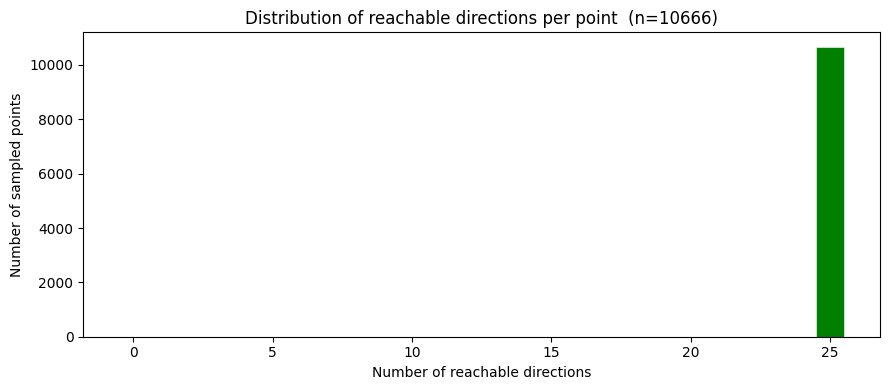

Unreachable points : 0/10666  (0.0%)
Max directions     : 25
Min directions     : 25
Mean directions    : 25.00
Median directions  : 25.0


In [9]:
counts = np.array([len(r["poses"]) for r in results])
_use_hist = len(counts) > 200  # bar chart is unreadable past ~200 points

fig, ax = plt.subplots(figsize=(9, 4))

if _use_hist:
    # Histogram: distribution of reachable-direction counts
    max_c = int(counts.max())
    bins  = np.arange(-0.5, max_c + 1.5, 1)
    n_hist, _, patches = ax.hist(counts, bins=bins, edgecolor="white", linewidth=0.4)
    # Colour bin 0 red, rest green
    for patch, left in zip(patches, bins[:-1]):
        patch.set_facecolor("red" if left < 0.5 else "green")
    ax.set_xlabel("Number of reachable directions")
    ax.set_ylabel("Number of sampled points")
    ax.set_title(f"Distribution of reachable directions per point  (n={len(counts)})")
else:
    # Bar chart for small meshes
    colors = ["green" if c > 0 else "red" for c in counts]
    ax.bar(range(len(counts)), counts, color=colors, edgecolor="white", linewidth=0.4)
    ax.set_xlabel("Sampled point index")
    ax.set_ylabel("Number of reachable directions")
    ax.set_title("Reachable directions per sampled face point")
    ax.axhline(0, color="black", linewidth=0.6)

plt.tight_layout()
plt.show()

unreachable_pct = 100.0 * (counts == 0).sum() / len(counts)
print(f"Unreachable points : {(counts == 0).sum()}/{len(counts)}  ({unreachable_pct:.1f}%)")
print(f"Max directions     : {counts.max()}")
print(f"Min directions     : {counts.min()}")
print(f"Mean directions    : {counts.mean():.2f}")
print(f"Median directions  : {np.median(counts):.1f}")
